# SchoolMove — GeneActiv Accelerometer EDA
**Subject:** 4001 | **Device:** GeneActiv 1.1 (serial 068006) | **Location:** Left Wrist  
**Recording start:** 2026-02-05 12:22:19.5 | **Sampling rate:** 100 Hz  

> **Note:** The current CSV file is a 3-row sample extract. The full recording at 100 Hz would contain millions of rows. This notebook is structured to scale to the full dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

DATA_PATH = os.path.join("..", "data", "fvb_data.csv")

print("Working directory:", os.getcwd())
print("Data file exists: ", os.path.exists(DATA_PATH))

Working directory: c:\Users\astri\Desktop\Data_Scientist\Projects\SchoolMove\notebooks
Data file exists:  True


## 1. Device & Study Metadata
The CSV header (lines 1–100) contains device configuration, subject info, and sensor specifications.  
We parse it here to understand what was measured and at what precision.

In [ ]:
metadata = {}
sensors = []
current_sensor = {}

with open(DATA_PATH, "r") as f:
    for i, line in enumerate(f):
        if i >= 100:
            break
        line = line.strip()
        if not line:
            if current_sensor:
                sensors.append(current_sensor)
                current_sensor = {}
            continue
        if "," in line:
            key, *rest = line.split(",", 1)
            val = rest[0].strip() if rest else ""
            key = key.strip()
            if key == "Sensor type":
                if current_sensor:
                    sensors.append(current_sensor)
                current_sensor = {"Sensor type": val}
            elif key in ("Range", "Resolution", "Units", "Additional information") and current_sensor:
                current_sensor[key] = val
            else:
                metadata[key] = val

if current_sensor:
    sensors.append(current_sensor)

# --- Device & Study Info ---
print("=== Device & Study Info ===")
important_keys = [
    "Device Type", "Device Model", "Device Unique Serial Code",
    "Device Firmware Version", "Measurement Frequency",
    "Start Time", "Device Location Code", "Time Zone",
    "Subject Code", "Config Time", "Extract Time"
]
for k in important_keys:
    if k in metadata:
        print(f"  {k:<35s}: {metadata[k]}")

# --- Sensor Specifications Table ---
print("\n=== Sensor Specifications ===")
sensor_df = pd.DataFrame(sensors)
display(sensor_df)

=== Device & Study Info ===
  Device Type                        : GENEActiv
  Device Model                       : 1.1
  Device Unique Serial Code          : 068006
  Device Firmware Version            : Ver4.08a date14Jul14
  Measurement Frequency              : 100 Hz
  Start Time                         : 2026-02-05 12:22:19:500
  Device Location Code               : left wrist
  Time Zone                          : GMT +01:00
  Subject Code                       : 4001
  Config Time                        : 2026-02-04 14:38:35:114
  Extract Time                       : 2026-02-17 11:50:43:998

=== Sensor Specifications ===


,Sensor type,Range,Resolution,Units,Additional information
0,MEMS accelerometer x-axis,-8 to 8,0.0039,g,
1,MEMS accelerometer y-axis,-8 to 8,0.0039,g,
2,MEMS accelerometer z-axis,-8 to 8,0.0039,g,
3,Lux Photodiode 400nm - 1100nm,0 to 5000,5,lux,
4,User button event marker,1 or 0,,,1=pressed
5,Linear active thermistor,0 to 70,0.1,deg. C,


## 2. Data Loading
The actual data starts at line 101 of the CSV. We skip the 100-line metadata header and assign human-readable column names.  
Columns 8–12 are computed/aggregated metrics whose exact meaning requires the documentation in `info/Info metingen.docx`.

In [ ]:
COLUMN_NAMES = [
    "timestamp",
    "accel_x",    # Accelerometer X (g)
    "accel_y",    # Accelerometer Y (g)
    "accel_z",    # Accelerometer Z (g)
    "lux",        # Light intensity (g lux) 
    "button_event",  # Button press marker (0/1)
    "temperature",   # Device temperature (deg C)
    "SVMg",      # Computed metric — SVMg (som van de means van g) <=> ENMO?
    "std_x",      # Computed metric — std X
    "std_y",     # Computed metric — std Y
    "std_z",     # Computed metric — std Z
    "max_lux",     # Computed metric — max (lux)
]

df = pd.read_csv(
    DATA_PATH,
    skiprows=100,
    header=None,
    names=COLUMN_NAMES,
)

# GeneActiv timestamp format: YYYY-MM-DD HH:MM:SS:mmm  (colon before milliseconds)
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%d %H:%M:%S:%f")
df = df.set_index("timestamp")

print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
print(f"Time range: {df.index.min()}  →  {df.index.max()}")
df.head()

Loaded 3 rows, 11 columns
Time range: 2026-02-05 12:22:24  →  2026-02-05 12:22:26


,accel_x,accel_y,accel_z,lux,button_event,temperature,col_8,col_9,col_10,col_11,col_12
timestamp,,,,,,,,,,,
2026-02-05 12:22:24,0.7198,0.2603,-0.5787,41,0,23.1,5.88,0.1425,0.1551,0.0968,70
2026-02-05 12:22:25,0.5624,0.3652,-0.6915,65,0,22.1,6.54,0.1745,0.1326,0.1435,247
2026-02-05 12:22:26,0.1966,0.2316,-0.7956,159,0,22.1,14.79,0.3565,0.4266,0.1896,247


## 3. Data Overview
Shape, column types, sample values, and a completeness check.

In [ ]:
print("=== Shape ===")
print(f"  {df.shape[0]} rows × {df.shape[1]} columns")

print("\n=== Data Types ===")
print(df.dtypes.to_string())

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing.to_string())
print(f"  → Total missing: {missing.sum()}")

print("\n=== Value Range (min / max) ===")
display(df.agg(["min", "max"]))

=== Shape ===
  3 rows × 11 columns

=== Data Types ===
accel_x         float64
accel_y         float64
accel_z         float64
lux               int64
button_event      int64
temperature     float64
col_8           float64
col_9           float64
col_10          float64
col_11          float64
col_12            int64

=== Missing Values ===
accel_x         0
accel_y         0
accel_z         0
lux             0
button_event    0
temperature     0
col_8           0
col_9           0
col_10          0
col_11          0
col_12          0
  → Total missing: 0

=== Value Range (min / max) ===


,accel_x,accel_y,accel_z,lux,button_event,temperature,col_8,col_9,col_10,col_11,col_12
min,0.1966,0.2316,-0.7956,41,0,22.1,5.88,0.1425,0.1326,0.0968,70
max,0.7198,0.3652,-0.5787,159,0,23.1,14.79,0.3565,0.4266,0.1896,247


## 4. Descriptive Statistics
Per-column summary statistics, with range utilisation shown relative to the device's known sensor limits.

In [ ]:
print("=== Descriptive Statistics ===")
display(df.describe().T)

# Known hardware ranges (from metadata header)
SENSOR_RANGES = {
    "accel_x":      (-8,    8,    "g"),
    "accel_y":      (-8,    8,    "g"),
    "accel_z":      (-8,    8,    "g"),
    "lux":          (0,     5000, "lux"),
    "button_event": (0,     1,    "binary"),
    "temperature":  (0,     70,   "deg C"),
}

print("\n=== Sensor Range Utilisation (% of hardware range observed in this sample) ===")
for col, (lo, hi, unit) in SENSOR_RANGES.items():
    if col not in df.columns:
        continue
    observed_span = df[col].max() - df[col].min()
    hardware_span = hi - lo
    pct = (observed_span / hardware_span) * 100
    print(
        f"  {col:<15s}: observed [{df[col].min():.4g} — {df[col].max():.4g}] {unit}"
        f"   ({pct:.2f}% of sensor range)"
    )

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
accel_x,3.0,0.492933,0.268428,0.1966,0.37950,0.5624,0.64110,0.7198
accel_y,3.0,0.285700,0.070329,0.2316,0.24595,0.2603,0.31275,0.3652
accel_z,3.0,-0.688600,0.108479,-0.7956,-0.74355,-0.6915,-0.63510,-0.5787
lux,3.0,88.333333,62.364520,41.0000,53.00000,65.0000,112.00000,159.0000
button_event,3.0,0.000000,0.000000,0.0000,0.00000,0.0000,0.00000,0.0000
temperature,3.0,22.433333,0.577350,22.1000,22.10000,22.1000,22.60000,23.1000
col_8,3.0,9.070000,4.964645,5.8800,6.21000,6.5400,10.66500,14.7900
col_9,3.0,0.224500,0.115430,0.1425,0.15850,0.1745,0.26550,0.3565
col_10,3.0,0.238100,0.163633,0.1326,0.14385,0.1551,0.29085,0.4266
col_11,3.0,0.143300,0.046400,0.0968,0.12015,0.1435,0.16655,0.1896



=== Sensor Range Utilisation (% of hardware range observed in this sample) ===
  accel_x        : observed [0.1966 — 0.7198] g   (3.27% of sensor range)
  accel_y        : observed [0.2316 — 0.3652] g   (0.84% of sensor range)
  accel_z        : observed [-0.7956 — -0.5787] g   (1.36% of sensor range)
  lux            : observed [41 — 159] lux   (2.36% of sensor range)
  button_event   : observed [0 — 0] binary   (0.00% of sensor range)
  temperature    : observed [22.1 — 23.1] deg C   (1.43% of sensor range)


## 5. Sensor-Specific Analysis

### 5a. Accelerometer (X / Y / Z)
At rest with gravity, the total vector magnitude should be ~1 g.  
We re-derive the Euclidean norm from the raw axes and compare it to `col_8` to understand what that column represents.

### 5b. Light (Lux)
### 5c. Temperature
### 5d. Button Events
### 5e. Computed Columns (col_8 – col_12)

In [ ]:
# ── Accelerometer ─────────────────────────────────────────────────────────────
print("=== Accelerometer (X / Y / Z) ===")
accel_cols = ["accel_x", "accel_y", "accel_z"]
display(df[accel_cols].describe())

dominant_axis = df[accel_cols].abs().mean().idxmax()
print(f"  Dominant gravity axis:  {dominant_axis}  (highest mean absolute value)")

# Re-derive Euclidean norm and compare to col_8
norm = np.sqrt((df["accel_x"]**2) + (df["accel_y"]**2) + (df["accel_z"]**2))
print(f"\n  Euclidean norm (sqrt(x²+y²+z²)):  {norm.values}")
print(f"  col_8 values:                     {df['col_8'].values}")
match = np.allclose(norm, df["col_8"], atol=0.01)
if match:
    print("  → col_8 matches the Euclidean norm (standard SVM).")
else:
    print("  → col_8 does NOT match the Euclidean norm — it is a different computed metric.")
    print("    Check 'info/Info metingen.docx' for the exact definition.")

print(f"\n  Mean acceleration vector: "
      f"[{df['accel_x'].mean():.4f}, {df['accel_y'].mean():.4f}, {df['accel_z'].mean():.4f}] g")

# ── Lux ───────────────────────────────────────────────────────────────────────
print("\n=== Light Intensity (Lux) ===")
print(df["lux"].describe().to_string())
lux_label = "outdoor/bright" if df["lux"].max() >= 1000 else "indoor ambient"
print(f"  Interpretation: {lux_label} lighting")
print(f"  Trend (increasing over sample): {df['lux'].is_monotonic_increasing}")

# ── Temperature ───────────────────────────────────────────────────────────────
print("\n=== Device Temperature ===")
print(df["temperature"].describe().to_string())
print(f"  Variation in sample: {df['temperature'].max() - df['temperature'].min():.1f} deg C")
print("  Note: reflects device/skin-contact temperature, not ambient air.")

# ── Button Events ─────────────────────────────────────────────────────────────
print("\n=== Button Events ===")
print(f"  Unique values:     {sorted(df['button_event'].unique())}")
print(f"  Button presses:    {(df['button_event'] == 1).sum()} row(s) with value = 1")

# ── Computed Columns ──────────────────────────────────────────────────────────
print("\n=== Computed / Unknown Columns (col_8 – col_12) ===")
computed_cols = ["col_8", "col_9", "col_10", "col_11", "col_12"]
display(df[computed_cols].describe())
print(f"  col_12 unique values: {df['col_12'].unique()}  — possibly epoch sample count or step counter")

=== Accelerometer (X / Y / Z) ===


,accel_x,accel_y,accel_z
count,3.000000,3.000000,3.000000
mean,0.492933,0.285700,-0.688600
std,0.268428,0.070329,0.108479
min,0.196600,0.231600,-0.795600
25%,0.379500,0.245950,-0.743550
50%,0.562400,0.260300,-0.691500
75%,0.641100,0.312750,-0.635100
max,0.719800,0.365200,-0.578700


  Dominant gravity axis:  accel_z  (highest mean absolute value)

  Euclidean norm (sqrt(x²+y²+z²)):  [0.95956335 0.96324299 0.85162755]
  col_8 values:                     [ 5.88  6.54 14.79]
  → col_8 does NOT match the Euclidean norm — it is a different computed metric.
    Check 'info/Info metingen.docx' for the exact definition.

  Mean acceleration vector: [0.4929, 0.2857, -0.6886] g

=== Light Intensity (Lux) ===
count      3.000000
mean      88.333333
std       62.364520
min       41.000000
25%       53.000000
50%       65.000000
75%      112.000000
max      159.000000
  Interpretation: indoor ambient lighting
  Trend (increasing over sample): True

=== Device Temperature ===
count     3.000000
mean     22.433333
std       0.577350
min      22.100000
25%      22.100000
50%      22.100000
75%      22.600000
max      23.100000
  Variation in sample: 1.0 deg C
  Note: reflects device/skin-contact temperature, not ambient air.

=== Button Events ===
  Unique values:     [np.int64(0

,col_8,col_9,col_10,col_11,col_12
count,3.000000,3.00000,3.000000,3.00000,3.000000
mean,9.070000,0.22450,0.238100,0.14330,188.000000
std,4.964645,0.11543,0.163633,0.04640,102.190998
min,5.880000,0.14250,0.132600,0.09680,70.000000
25%,6.210000,0.15850,0.143850,0.12015,158.500000
50%,6.540000,0.17450,0.155100,0.14350,247.000000
75%,10.665000,0.26550,0.290850,0.16655,247.000000
max,14.790000,0.35650,0.426600,0.18960,247.000000


  col_12 unique values: [ 70 247]  — possibly epoch sample count or step counter


## 6. Visualizations
Time series plots for all sensor channels.  
With 3 data points this shows the structure and approach; the same code scales to the full dataset.

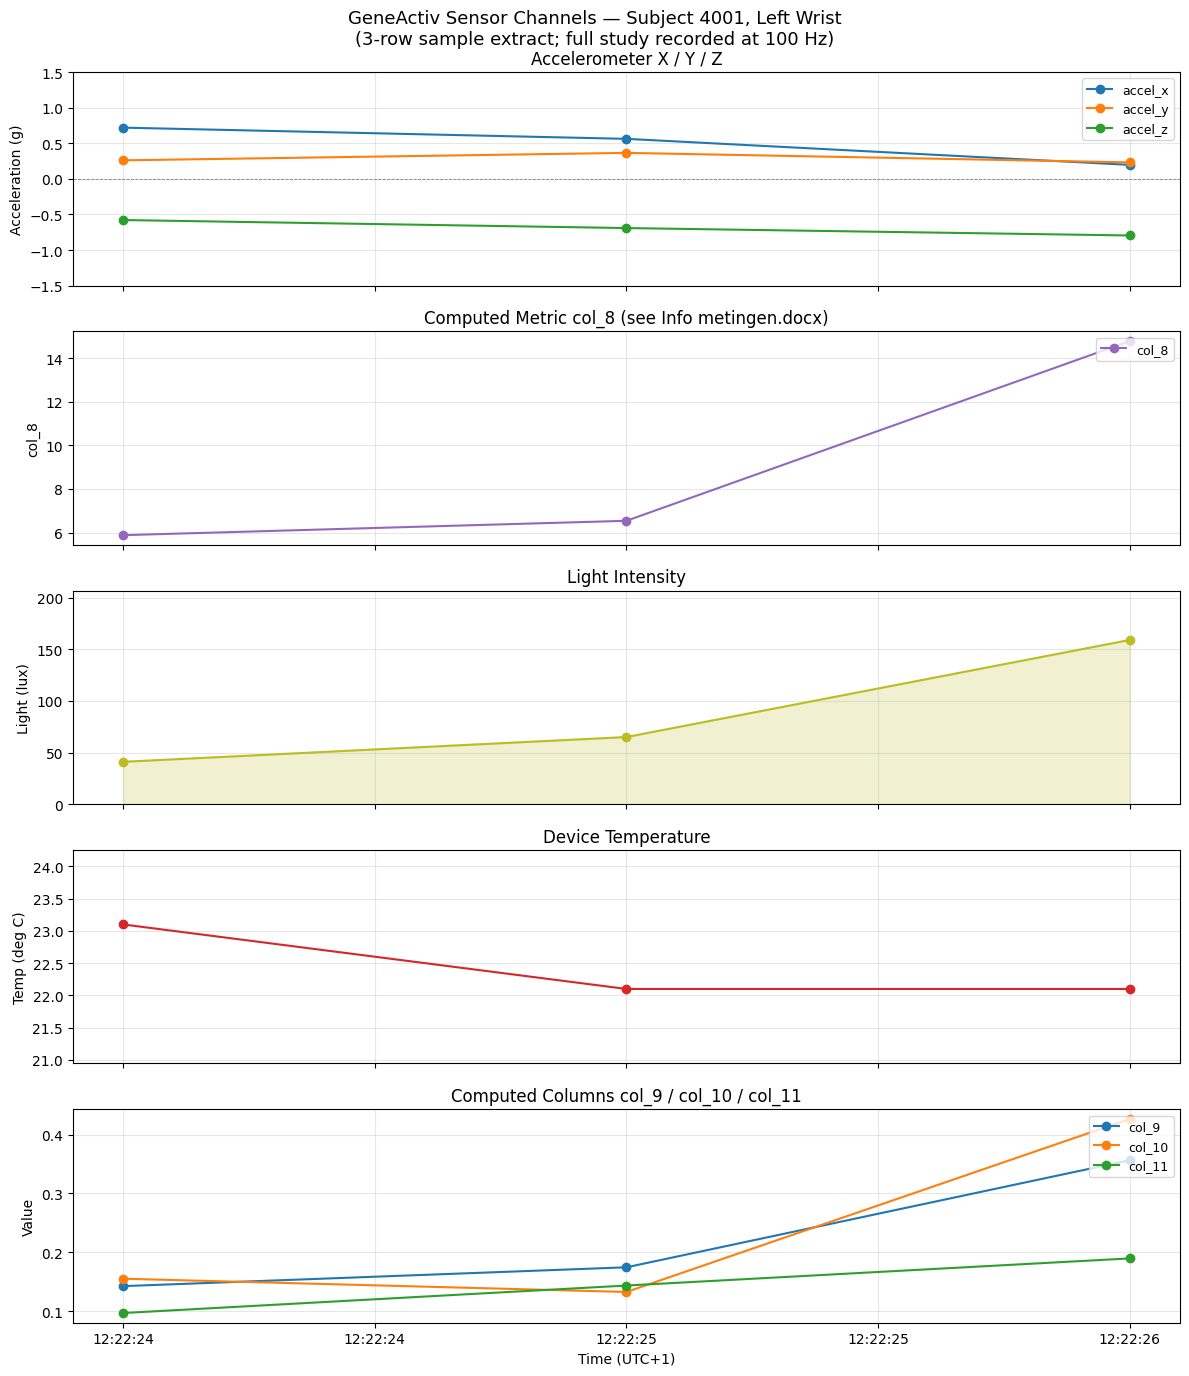

Figure saved → ..\data\sensor_overview.png


In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)
fig.suptitle(
    "GeneActiv Sensor Channels — Subject 4001, Left Wrist\n"
    "(3-row sample extract; full study recorded at 100 Hz)",
    fontsize=13
)

t = df.index

# Panel 1 — Accelerometer X / Y / Z
ax = axes[0]
colors = {"accel_x": "tab:blue", "accel_y": "tab:orange", "accel_z": "tab:green"}
for col, color in colors.items():
    ax.plot(t, df[col], marker="o", label=col, color=color)
ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax.set_ylabel("Acceleration (g)")
ax.set_title("Accelerometer X / Y / Z")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(-1.5, 1.5)

# Panel 2 — col_8 (computed metric)
ax = axes[1]
ax.plot(t, df["col_8"], marker="o", color="tab:purple", label="col_8")
ax.set_ylabel("col_8")
ax.set_title("Computed Metric col_8 (see Info metingen.docx)")
ax.legend(loc="upper right", fontsize=9)

# Panel 3 — Light (Lux)
ax = axes[2]
ax.plot(t, df["lux"], marker="o", color="tab:olive", label="Lux")
ax.fill_between(t, df["lux"], alpha=0.2, color="tab:olive")
ax.set_ylabel("Light (lux)")
ax.set_title("Light Intensity")
ax.set_ylim(0, max(df["lux"].max() * 1.3, 50))

# Panel 4 — Temperature
ax = axes[3]
ax.plot(t, df["temperature"], marker="o", color="tab:red", label="Temperature")
ax.set_ylabel("Temp (deg C)")
ax.set_title("Device Temperature")
temp_margin = max(df["temperature"].std() * 2, 1)
ax.set_ylim(df["temperature"].min() - temp_margin, df["temperature"].max() + temp_margin)

# Panel 5 — Accelerometer window SDs (col_9, col_10, col_11)
ax = axes[4]
for col, color in zip(["col_9", "col_10", "col_11"], ["tab:blue", "tab:orange", "tab:green"]):
    ax.plot(t, df[col], marker="o", label=col, color=color)
ax.set_ylabel("Value")
ax.set_title("Computed Columns col_9 / col_10 / col_11")
ax.legend(loc="upper right", fontsize=9)

# Shared x-axis formatting
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (UTC+1)")
plt.tight_layout()

out_path = os.path.join("..", "data", "sensor_overview.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {out_path}")

## 7. Summary & Key Findings

In [ ]:
sep = "=" * 62
print(sep)
print("  SCHOOLMOVE EDA SUMMARY — Subject 4001")
print(sep)

duration_sec = (df.index.max() - df.index.min()).total_seconds()
print(f"\nSample rows:       {len(df)}  ({duration_sec:.0f} s)")
print(f"Columns:           {len(df.columns)}")

print("\n── Accelerometer ─────────────────────────────────────────")
print(f"  Mean vector:     [{df['accel_x'].mean():.3f}, {df['accel_y'].mean():.3f}, {df['accel_z'].mean():.3f}] g")
print(f"  Dominant axis:   {df[['accel_x','accel_y','accel_z']].abs().mean().idxmax()}")

print("\n── Light ──────────────────────────────────────────────────")
print(f"  Mean lux:        {df['lux'].mean():.1f}")
print(f"  Range:           {df['lux'].min()} – {df['lux'].max()} lux")

print("\n── Temperature ────────────────────────────────────────────")
print(f"  Mean:            {df['temperature'].mean():.1f} deg C")
print(f"  Range:           {df['temperature'].min()} – {df['temperature'].max()} deg C")

print("\n── Button Events ──────────────────────────────────────────")
print(f"  Presses (=1):    {(df['button_event'] == 1).sum()}")

print("\n── Data Quality ───────────────────────────────────────────")
print(f"  Missing values:  {df.isnull().sum().sum()}")
diffs = df.index.to_series().diff().dropna()
print(f"  Timestamp gaps:  {diffs.unique()}")

print("\n── col_8 identity ─────────────────────────────────────────")
norm = np.sqrt((df['accel_x']**2) + (df['accel_y']**2) + (df['accel_z']**2))
match = np.allclose(norm, df['col_8'], atol=0.01)
print(f"  Matches Euclidean norm: {match}")
if not match:
    print("  → Definition unclear. Consult 'info/Info metingen.docx'.")

print("\n── Next Steps (for full dataset) ──────────────────────────")
next_steps = [
    "Load full CSV (expected >1M rows at 100 Hz)",
    "Resample to 1-min or 5-min epochs for activity patterns",
    "Clarify meaning of col_8 – col_12 via documentation",
    "Apply ENMO (Euclidean Norm Minus One) for activity intensity",
    "Cross-reference lux for indoor/outdoor context",
    "Classify sleep / sedentary / active periods",
]
for i, step in enumerate(next_steps, 1):
    print(f"  {i}. {step}")

print(f"\n{sep}")

  SCHOOLMOVE EDA SUMMARY — Subject 4001

Sample rows:       3  (2 s)
Columns:           11

── Accelerometer ─────────────────────────────────────────
  Mean vector:     [0.493, 0.286, -0.689] g
  Dominant axis:   accel_z

── Light ──────────────────────────────────────────────────
  Mean lux:        88.3
  Range:           41 – 159 lux

── Temperature ────────────────────────────────────────────
  Mean:            22.4 deg C
  Range:           22.1 – 23.1 deg C

── Button Events ──────────────────────────────────────────
  Presses (=1):    0

── Data Quality ───────────────────────────────────────────
  Missing values:  0
  Timestamp gaps:  <TimedeltaArray>
['0 days 00:00:01']
Length: 1, dtype: timedelta64[ns]

── col_8 identity ─────────────────────────────────────────
  Matches Euclidean norm: False
  → Definition unclear. Consult 'info/Info metingen.docx'.

── Next Steps (for full dataset) ──────────────────────────
  1. Load full CSV (expected >1M rows at 100 Hz)
  2. Resample to 